<a href="https://colab.research.google.com/github/HinaH1/dental-caries-detection-segmentation/blob/main/phase_one/initial_experiment_one_ipnyb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment One: YOLOv8 Object Detection Baseline

## Overview
This notebook documents the first experiment of Phase One. A YOLOv8 object
detection model was trained on the Kaggle dental cavity radiograph dataset to
establish a detection baseline and assess whether bounding box outputs were
sufficient for localising carious lesions. The findings from this experiment
informed the decision to move to instance segmentation in Experiments Two and Three.

## Dataset
The dataset used in this experiment was the Dental Cavity Radiograph Images dataset,
sourced from Kaggle (alokkumar175358).

## Training Configuration
- Model: YOLOv8n (nano)
- Epochs: 50
- Image size: 640 pixels
- Batch size: 16

## Environment Setup
The following cell checks the GPU available in this session and installs
the required libraries.

In [1]:
!nvidia-smi
!pip -q install ultralytics opencv-python pillow tqdm pyyaml scikit-learn

Sun Apr 19 19:00:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Dataset Download
The dataset is downloaded from Kaggle using the Kaggle API.
To run this notebook, replace the placeholder values below with
your own Kaggle credentials, which can be found in your Kaggle
account settings under API.

In [2]:
import os

os.environ['KAGGLE_USERNAME'] = 'YOUR_KAGGLE_USERNAME'
os.environ['KAGGLE_KEY'] = 'YOUR_KAGGLE_KEY'

!pip -q install kaggle
!mkdir -p /content/cavity_data
!kaggle datasets download -d alokkumar175358/dental-cavity-radiograph-images \
    -p /content/cavity_data --unzip
!ls -la /content/cavity_data

Dataset URL: https://www.kaggle.com/datasets/alokkumar175358/dental-cavity-radiograph-images
License(s): MIT
100% 13.2M/13.2M [00:01<00:00, 7.24MB/s]

total 32
drwxr-xr-x 5 root root 4096 Apr 19 19:00 .
drwxr-xr-x 1 root root 4096 Apr 19 19:00 ..
-rw-r--r-- 1 root root  263 Apr 19 19:00 data.yaml
-rw-r--r-- 1 root root  145 Apr 19 19:00 README.dataset.txt
-rw-r--r-- 1 root root 1073 Apr 19 19:00 README.roboflow.txt
drwxr-xr-x 4 root root 4096 Apr 19 19:00 test
drwxr-xr-x 4 root root 4096 Apr 19 19:00 train
drwxr-xr-x 4 root root 4096 Apr 19 19:00 valid


## Dataset Structure
The following cell explores the dataset structure to confirm it matches the YOLO expected format before training begins.

In [3]:
!find /content/cavity_data -maxdepth 4 -type d -print
!cat /content/cavity_data/data.yaml

/content/cavity_data
/content/cavity_data/train
/content/cavity_data/train/images
/content/cavity_data/train/labels
/content/cavity_data/valid
/content/cavity_data/valid/images
/content/cavity_data/valid/labels
/content/cavity_data/test
/content/cavity_data/test/images
/content/cavity_data/test/labels
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['Cavity']

roboflow:
  workspace: infotsav
  project: dental-images-mvmez
  version: 3
  license: CC BY 4.0
  url: https://universe.roboflow.com/infotsav/dental-images-mvmez/dataset/3

## Sample Images
Next, we display a sample of training images to
visually inspect the dataset before training.

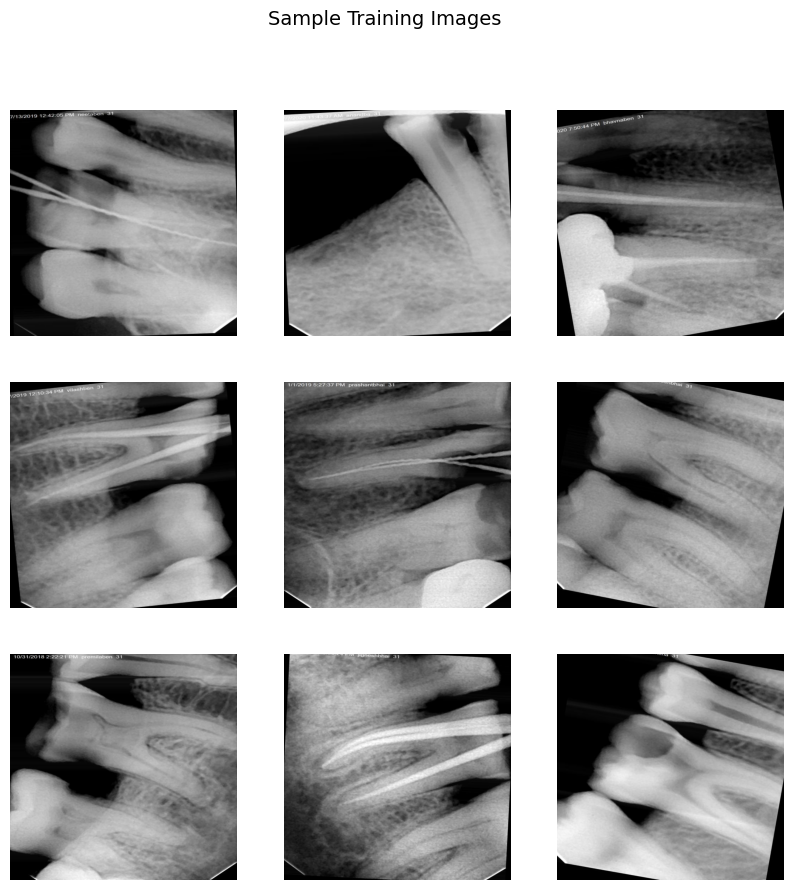

In [4]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_dir = Path("/content/cavity_data/train/images")
imgs = random.sample(list(img_dir.glob("*.jpg")), 9)

plt.figure(figsize=(10,10))
for i, p in enumerate(imgs, 1):
    plt.subplot(3, 3, i)
    plt.imshow(mpimg.imread(p), cmap="gray")
    plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14)
plt.show()

## Model Training
A YOLOv8 nano detection model was trained on the dataset for 50 epochs
with an image size of 640 pixels and a batch size of 16. The nano variant
was selected as it is the most computationally efficient configuration,
suitable for the dataset size used in this preliminary experiment.

In [5]:
%cd /content/cavity_data
!yolo detect train data=data.yaml model=yolov8n.pt imgsz=640 epochs=50 batch=16

/content/cavity_data
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, 

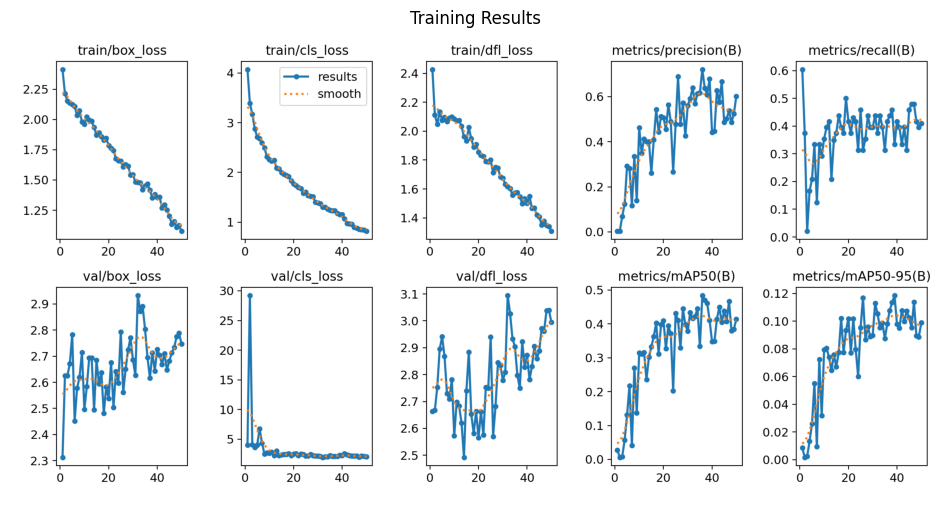

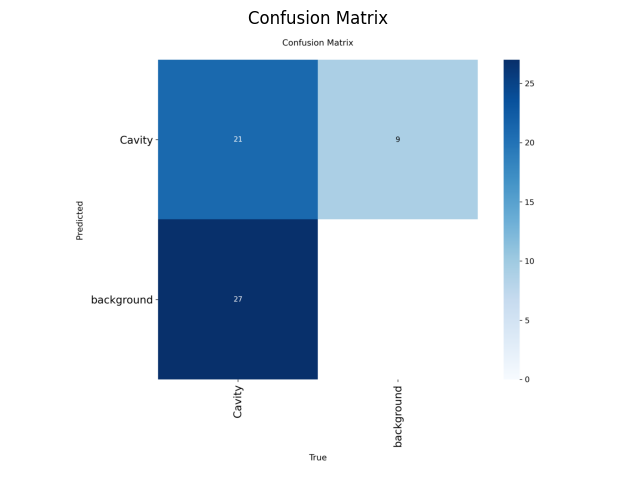

In [6]:
# Display training results
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

results_path = "/content/cavity_data/runs/detect/train/"

# Plot results
img = mpimg.imread(results_path + "results.png")
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Training Results")
plt.show()

# Plot confusion matrix
cm = mpimg.imread(results_path + "confusion_matrix.png")
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

## Results
The training output above shows the model performance across epochs.
The results demonstrated that bounding box outputs struggled to accurately
capture the irregular and diffuse boundaries characteristic of carious lesions,
confirming that detection alone is insufficient for precise lesion localisation.
This finding motivated the transition to instance segmentation in Experiments
Two and Three.